# Validation finale du modèle

## Objectif

Cette partie consiste à effectuer la validation finale du modèle sélectionné sur le jeu de test.

L'objectif est d'évaluer ses performances sur des données qui n'ont pas été utilisées lors de l'entraînement ni lors de l'optimisation des hyperparamètres.

Les résultats obtenus seront analysés afin d'évaluer la capacité de généralisation du modèle et ses limites dans le contexte de prédiction du churn client.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from src.evaluation import evaluate_model
from src.models import create_random_forest
from src.preprocessing import build_preprocessor, clean_data
from src.visualization import plot_confusion_matrix, plot_roc_curve


In [2]:
df = pd.read_csv(PROJECT_ROOT / "data" / "raw" / "telco-customer-churn.csv")
df = clean_data(df)

y = df["Churn"].map({"No": 0, "Yes": 1})
X = df.drop(columns=["customerID", "Churn"])


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
preprocessor = build_preprocessor()

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)


In [5]:
final_model = create_random_forest(
    n_estimators=200, max_depth=10, min_samples_leaf=2, min_samples_split=2
)
final_model.fit(X_train_processed, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",2
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total n

In [6]:
y_pred = final_model.predict(X_test_processed)

print("=== VALIDATION FINALE ===\n")
print(pd.Series(evaluate_model(final_model, X_test_processed, y_test)).round(4))

print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))


=== VALIDATION FINALE ===

Accuracy     0.8041
Precision    0.6667
Recall       0.5241
F1-score     0.5868
ROC-AUC      0.8438
dtype: float64

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       0.84      0.91      0.87      1035
           1       0.67      0.52      0.59       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.73      1409
weighted avg       0.79      0.80      0.80      1409



[[937  98]
 [178 196]]


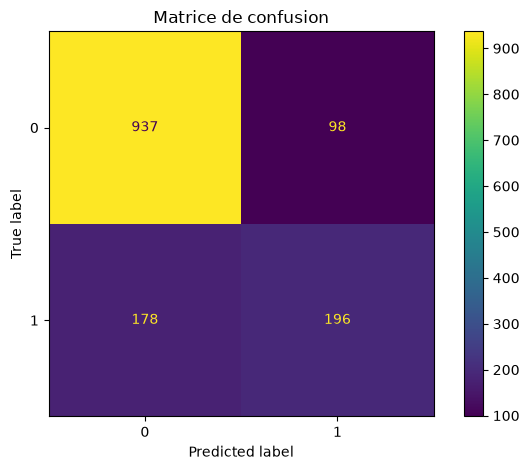

In [7]:
cm = confusion_matrix(y_test, y_pred)
print(cm)
plot_confusion_matrix(final_model, X_test_processed, y_test)


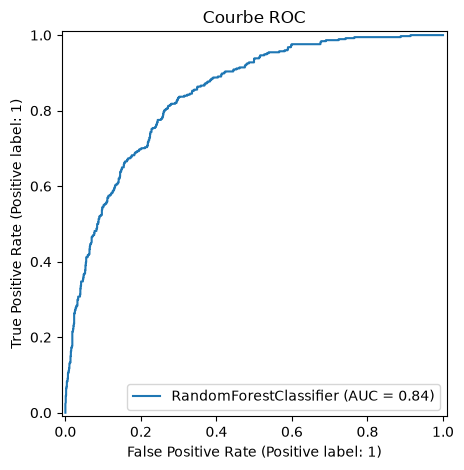

In [8]:
plot_roc_curve(final_model, X_test_processed, y_test)


## Analyse de la généralisation

Le modèle final est évalué sur un jeu de test représentant 20 % des observations, qui n'a pas été utilisé pour l'entraînement ni pour l'optimisation des hyperparamètres.

Le Random Forest optimisé obtient un ROC-AUC de 0,8438 sur le jeu de test, ce qui indique une bonne capacité à distinguer les clients susceptibles de churner des clients qui restent.

Les performances obtenues sur le jeu de test sont proches de celles observées lors de la validation croisée, avec un ROC-AUC de 0,8435. Cette proximité suggère une bonne stabilité du modèle et l'absence d'un écart important entre les performances observées pendant l'optimisation et celles obtenues sur des données non utilisées.

Le recall de 52,41 % montre cependant que le modèle ne détecte qu'environ la moitié des clients ayant réellement churné. Cette limite doit être prise en compte dans une utilisation opérationnelle du modèle.

In [9]:
feature_names = preprocessor.get_feature_names_out()

feature_importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": final_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Variable,Importance
0,num__tenure,0.198270
2,num__TotalCharges,0.153570
1,num__MonthlyCharges,0.115786
10,cat__InternetService_Fiber optic,0.070254
28,cat__PaymentMethod_Electronic check,0.065558
25,cat__Contract_Two year,0.059497
24,cat__Contract_One year,0.034083
13,cat__OnlineSecurity_Yes,0.033903
19,cat__TechSupport_Yes,0.025335
26,cat__PaperlessBilling_Yes,0.021364


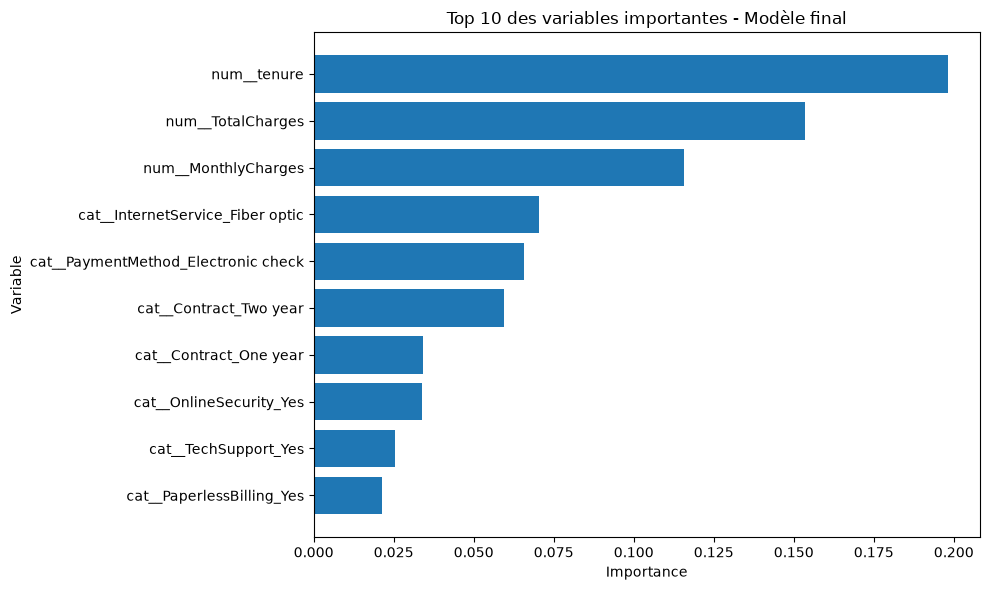

In [10]:
top_features = feature_importance.head(10).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Variable"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Top 10 des variables importantes - Modèle final")

plt.tight_layout()
plt.show()

In [11]:
# Analyse de la généralisation
y_train_pred = final_model.predict(X_train_processed)

train_metrics = evaluate_model(final_model, X_train_processed, y_train)
test_metrics = evaluate_model(final_model, X_test_processed, y_test)

comparison = pd.DataFrame([train_metrics, test_metrics], index=["Train", "Test"])
comparison


,Accuracy,Precision,Recall,F1-score,ROC-AUC
Train,0.856763,0.792517,0.623411,0.697866,0.934074
Test,0.804116,0.666667,0.524064,0.586826,0.843795


In [12]:
print("=== ANALYSE DE LA GÉNÉRALISATION ===\n")
print(comparison.round(4))

roc_gap = train_metrics["ROC-AUC"] - test_metrics["ROC-AUC"]

print(f"\nÉcart ROC-AUC Train/Test : {roc_gap:.4f}")

if roc_gap < 0.05:
    print("Le modèle présente un écart limité entre les performances d'entraînement et de test.")
    print("La généralisation est considérée comme satisfaisante.")
else:
    print("Un écart important est observé entre l'entraînement et le test.")
    print("Une possible situation de surapprentissage doit être surveillée.")

=== ANALYSE DE LA GÉNÉRALISATION ===

       Accuracy  Precision  Recall  F1-score  ROC-AUC
Train    0.8568     0.7925  0.6234    0.6979   0.9341
Test     0.8041     0.6667  0.5241    0.5868   0.8438

Écart ROC-AUC Train/Test : 0.0903
Un écart important est observé entre l'entraînement et le test.
Une possible situation de surapprentissage doit être surveillée.


In [13]:
# Analyse des erreurs de classification

cm = confusion_matrix(y_test, y_pred)

tn, fp, fn, tp = cm.ravel()

print("=== ANALYSE DES ERREURS ===")
print(f"Vrais négatifs  : {tn}")
print(f"Faux positifs   : {fp}")
print(f"Faux négatifs   : {fn}")
print(f"Vrais positifs  : {tp}")

print(f"\nClients ayant réellement churné : {fn + tp}")
print(f"Clients churnés correctement détectés : {tp}")
print(f"Clients churnés non détectés : {fn}")

print(
    f"\nTaux de détection des churners : "
    f"{tp / (fn + tp) * 100:.2f}%"
)

=== ANALYSE DES ERREURS ===
Vrais négatifs  : 937
Faux positifs   : 98
Faux négatifs   : 178
Vrais positifs  : 196

Clients ayant réellement churné : 374
Clients churnés correctement détectés : 196
Clients churnés non détectés : 178

Taux de détection des churners : 52.41%


### Validation finale et généralisation

Le modèle final retenu est un Random Forest optimisé avec les hyperparamètres suivants :

- `n_estimators = 200`
- `max_depth = 10`
- `min_samples_leaf = 2`
- `min_samples_split = 2`

Le modèle est évalué sur un jeu de test représentant 20 % des données, avec une séparation stratifiée afin de conserver la proportion de clients ayant churné.

Les performances obtenues sur le jeu de test sont :

- Accuracy : 80,41 %
- Precision : 66,67 %
- Recall : 52,41 %
- F1-score : 58,68 %
- ROC-AUC : 84,38 %

Le ROC-AUC de 0,8438 indique une bonne capacité du modèle à distinguer les clients ayant churné des clients n'ayant pas churné.

L'analyse de la matrice de confusion montre toutefois que 178 clients ayant réellement churné ne sont pas détectés par le modèle. Le recall de 52,41 % constitue donc une limite importante dans un contexte où l'objectif est d'identifier les clients à risque.

La comparaison des performances entre les données d'entraînement et de test permet de vérifier la capacité du modèle à généraliser à de nouvelles données. L'écart entre ces deux ensembles doit rester limité afin de réduire le risque de surapprentissage.

### Conclusion

Le Random Forest optimisé constitue le modèle final retenu pour cette étude. Il offre le meilleur compromis parmi les modèles testés, notamment grâce à son ROC-AUC de 0,8438 et à sa précision de 66,67 % sur le jeu de test.

Les variables les plus importantes sont notamment l'ancienneté du client (`tenure`), le montant total facturé (`TotalCharges`), les charges mensuelles (`MonthlyCharges`), le type de service Internet et le mode de paiement.

Le modèle peut être utilisé comme outil d'aide à l'identification des clients présentant un risque de churn. Cependant, il ne doit pas être considéré comme une prédiction certaine. Une amélioration du recall pourrait être recherchée dans une évolution du projet, notamment par l'ajustement du seuil de classification ou par la prise en compte du déséquilibre des classes.

,Accuracy,Precision,Recall,F1-score,ROC-AUC
Logistic Regression,0.8055,0.6572,0.5588,0.6040,0.8413
Decision Tree,0.7956,0.6335,0.5455,0.5862,0.8270
Random Forest,0.8041,0.6667,0.5241,0.5868,0.8438


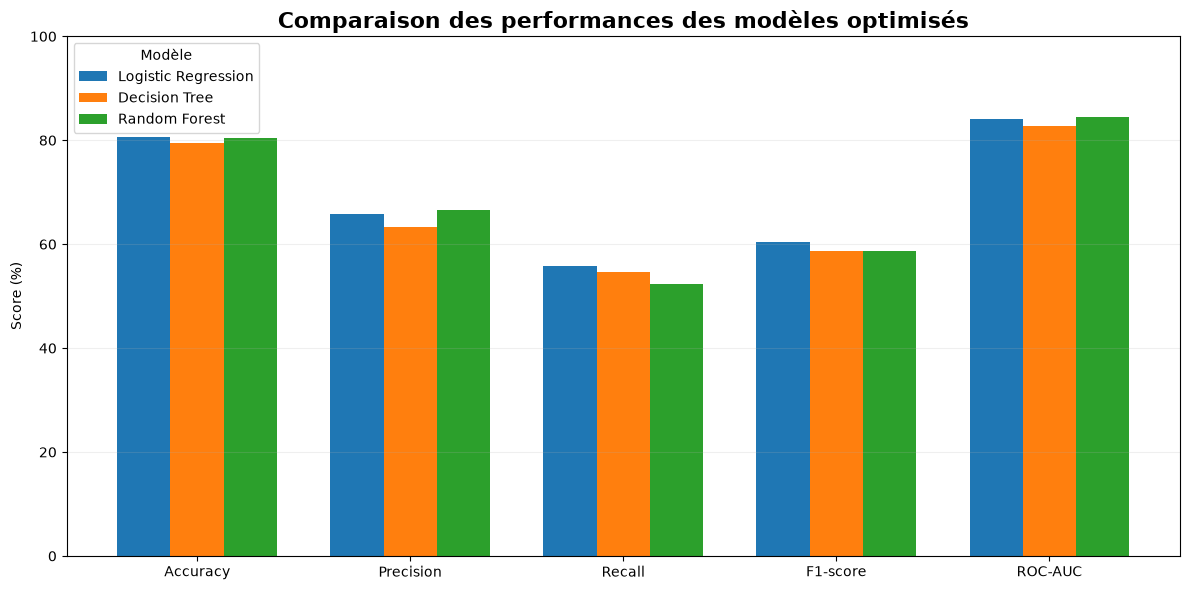

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Résultats des modèles optimisés sur le jeu de test
results = {
    "Logistic Regression": {
        "Accuracy": 0.8055,
        "Precision": 0.6572,
        "Recall": 0.5588,
        "F1-score": 0.6040,
        "ROC-AUC": 0.8413
    },
    "Decision Tree": {
        "Accuracy": 0.7956,
        "Precision": 0.6335,
        "Recall": 0.5455,
        "F1-score": 0.5862,
        "ROC-AUC": 0.8270
    },
    "Random Forest": {
        "Accuracy": 0.8041,
        "Precision": 0.6667,
        "Recall": 0.5241,
        "F1-score": 0.5868,
        "ROC-AUC": 0.8438
    }
}

# Création du DataFrame
results_df = pd.DataFrame(results).T

# Affichage du tableau
display(results_df.round(4))

# Création du graphique
metrics = results_df.columns
models = results_df.index

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

for i, model in enumerate(models):
    ax.bar(
        x + (i - 1) * width,
        results_df.loc[model] * 100,
        width,
        label=model
    )

# Mise en forme
ax.set_title(
    "Comparaison des performances des modèles optimisés",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel("Score (%)")
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 100)

ax.legend(title="Modèle")
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()